<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Drought_Severity_CensusTract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

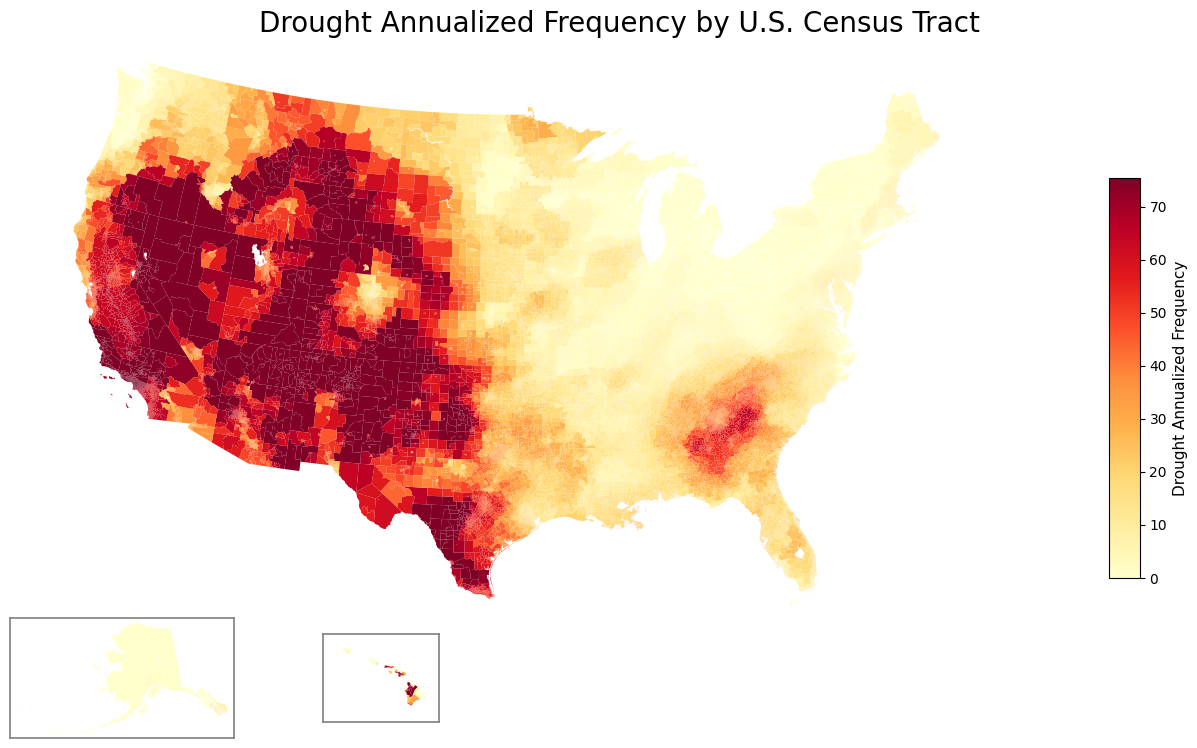

In [2]:
# Run once
# !pip install geopandas matplotlib numpy pandas

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Link to information download:
# https://resilience-fema.hub.arcgis.com/datasets/FEMA::national-risk-index-annualized-frequency-drought/explore?layer=1&location=42.595305%2C-93.749460%2C7

# Load drought census tract shapefile
gdf = gpd.read_file("/content/Census_Tract.shp")

# Make sure drought values are numeric
gdf["DRGT_AFREQ"] = pd.to_numeric(
    gdf["DRGT_AFREQ"],
    errors="coerce"
)

# Make sure coordinates are latitude/longitude first
gdf = gdf.to_crs(epsg=4326)

# Remove U.S. territories only
territories = [
    "Puerto Rico",
    "Virgin Islands",
    "Guam",
    "American Samoa",
    "Northern Mariana Islands"
]

gdf = gdf[~gdf["STATE"].isin(territories)].copy()

# Split into maps
lower48 = gdf[~gdf["STATE"].isin(["Alaska", "Hawaii"])].copy()
alaska = gdf[gdf["STATE"] == "Alaska"].copy()
hawaii = gdf[gdf["STATE"] == "Hawaii"].copy()

# Color scale
drought_values = gdf["DRGT_AFREQ"].dropna()
vmin = drought_values.quantile(0.02)
vmax = drought_values.quantile(0.98)

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Main Lower 48 map
ax_main = fig.add_axes([0.02, 0.18, 0.80, 0.75])

lower48_proj.plot(
    column="DRGT_AFREQ",
    cmap="YlOrRd",
    legend=False,
    edgecolor="none",
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax_main,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "none",
        "linewidth": 0
    }
)

ax_main.axis("off")

# Alaska inset box
ax_ak = fig.add_axes([0.05, 0.05, 0.19, 0.15])
ax_ak.set_facecolor("white")

alaska_proj.plot(
    column="DRGT_AFREQ",
    cmap="YlOrRd",
    legend=False,
    edgecolor="none",
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax_ak,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "none",
        "linewidth": 0
    }
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.03
y_buffer = (maxy - miny) * 0.03

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Hawaii inset box
ax_hi = fig.add_axes([0.28, 0.07, 0.10, 0.11])
ax_hi.set_facecolor("white")

hawaii_proj.plot(
    column="DRGT_AFREQ",
    cmap="YlOrRd",
    legend=False,
    edgecolor="none",
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax_hi,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "none",
        "linewidth": 0
    }
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Colorbar
ax_cbar = fig.add_axes([0.85, 0.25, 0.022, 0.50])

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm._A = []

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label("Drought Annualized Frequency", fontsize=11)

# Title
fig.suptitle(
    "Drought Annualized Frequency by U.S. Census Tract",
    fontsize=20,
    y=0.96
)

plt.show()